# Dimensionality Reduction & Feature Selection

This notebook tests various dimensionality reduction algorithms to assist in the learning of useful crisis precursor features. This problem suffers from high dimensionality, which can make it difficult for models to learn meaningful patterns. Since the data quality is of concern, especially for emerging markets, and since large portions of the dataset were imputed using history-based KNN, there is a need to create a feature space that is appropriately able to separate crisis periods and to understand how such a space organizes developed and emerging training and test data.

In [1]:
from src.model.utilities import set_seed, set_device
seed = set_seed()
device = set_device()

from src.features.utilities import load_or_train_model

import pandas as pd
import numpy as np

import os
import dotenv
dotenv.load_dotenv()
username = os.getenv("HUGGINGFACE_USERNAME")

No GPU available! Running on CPU


We use the data that was preprocessed at a monthly resolution. This includes:
1. Annual data from the **World Bank**
2. Annual data from the **JST Macrohistory Database**
3. Monthly data from **OECD** with some feature engineering

In [2]:
from datasets import load_dataset

datalink = f"{username}/imputed-monthly"
train_df = load_dataset(datalink, "developed", split='train').to_pandas()
test_df = load_dataset(datalink, "developed", split='test').to_pandas()
support_df = load_dataset(datalink, "emerging", split='train').to_pandas()
query_df = load_dataset(datalink, "emerging", split='test').to_pandas()

In [3]:
from src.data.data_utilities import build_labels

y_train = build_labels(train_df)
y_test = build_labels(test_df)
y_support = build_labels(support_df)
y_query = build_labels(query_df)

Once again, we remove the periods corresponding to the actual crisis and recovery by keeping every year with positive crisis label and dropping four years following positive crisis label, or all years until the next positive crisis label, whichever is shortest. This is to ensure that our dimensionality reduction is trying, as much as possible, to separate pre-crisis periods from a healthy economy rather than separating pre-crisis from in-crisis, recovery, and healthy periods. We do this only for the training period to simulate a real-world test scenario.

In [4]:
from src.data.data_utilities import drop_recovery

train_df, y_train = drop_recovery(train_df, y_train, recovery_years=4)
support_df, y_support = drop_recovery(support_df, y_support, recovery_years=4)

In [5]:
print(f"Countries in developed train set: {train_df['Country'].unique()}")
print(f"Date range in developed train set: {train_df['Date'].min()} to {train_df['Date'].max()}")
print(f"Crises in developed train set: {y_train.mean() * 100:.2f}%")
print("\n")
print(f"Countries in developed test set: {test_df['Country'].unique()}")
print(f"Date range in developed test set: {test_df['Date'].min()} to {test_df['Date'].max()}")
print(f"Crises in developed test set: {y_test.mean() * 100:.2f}%")
print("\n")
print(f"Countries in emerging train set: {support_df['Country'].nunique()}")
print(f"Date range in emerging train set: {support_df['Date'].min()} to {support_df['Date'].max()}")
print(f"Crises in emerging train set: {y_support.mean() * 100:.2f}%")
print("\n")
print(f"Countries in emerging test set: {query_df['Country'].nunique()}")
print(f"Date range in emerging test set: {query_df['Date'].min()} to {query_df['Date'].max()}")
print(f"Crises in emerging test set: {y_query.mean() * 100:.2f}%")

Countries in developed train set: ['Australia' 'Belgium' 'Canada' 'Denmark' 'Finland' 'France' 'Germany'
 'Italy' 'Japan' 'Netherlands' 'Norway' 'Portugal' 'Spain' 'Sweden'
 'Switzerland' 'United Kingdom' 'United States']
Date range in developed train set: 1960-01-31 00:00:00 to 2006-12-31 00:00:00
Crises in developed train set: 20.75%


Countries in developed test set: ['Australia' 'Belgium' 'Canada' 'Denmark' 'Finland' 'France' 'Germany'
 'Italy' 'Japan' 'Netherlands' 'Norway' 'Portugal' 'Spain' 'Sweden'
 'Switzerland' 'United Kingdom' 'United States']
Date range in developed test set: 2007-01-31 00:00:00 to 2023-12-31 00:00:00
Crises in developed test set: 6.92%


Countries in emerging train set: 73
Date range in emerging train set: 1962-12-31 00:00:00 to 2006-12-31 00:00:00
Crises in emerging train set: 21.87%


Countries in emerging test set: 73
Date range in emerging test set: 2007-01-31 00:00:00 to 2023-12-31 00:00:00
Crises in emerging test set: 9.91%


## Principal Component Analysis (PCA)

We start with a linear dimensionality reduction method such as PCA. Recall that many of the variables in the databases used for this project are highly correlated. This correlation is both within the database and across database columns. For example, there are many ways to report a country's GDP with small nuances such as raw US$ value based on current exchange rate or based on a historical base rate as well as GDP-derived features such as GDP per capita, GDP growth, and exports/imports as a function of GDP. These linear unit adjustments can be found and grouped into useful components using PCA.

Performing PCA on the developed data shows that there are natural separations between countries in the feature space created by the first two principal components, even when country identifiers are removed from the data. This means that the data is sufficiently country-specific, reinforcing that dummy encoding is not needed. However, there is no clear separation in the feature space between positive and negative crisis labels as both appear to occupy the same space and belong to the same clusters.

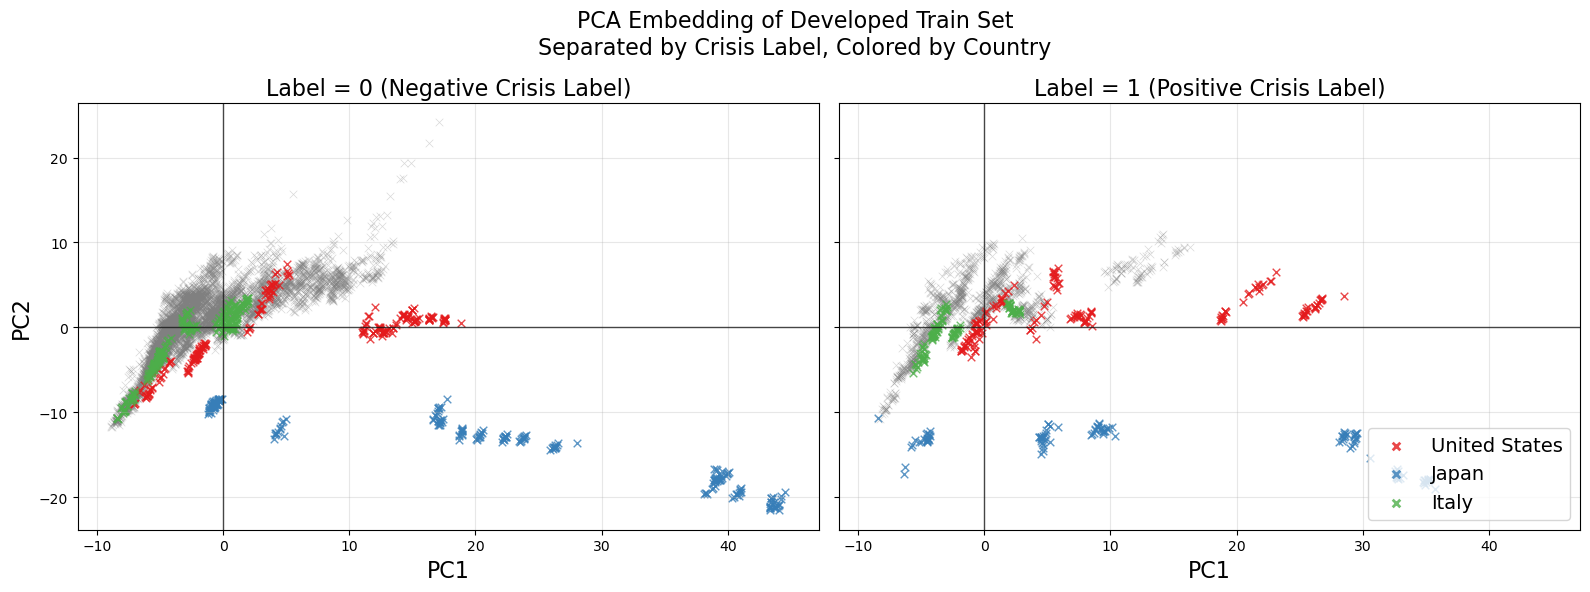

In [6]:
from src.features.pca import BasePCA

pca_class = BasePCA(n_components=0.95)
pca_class.fit(train_df.drop(columns=['Country', 'Date']), y_train)

transformed_train = pca_class.transform(train_df.drop(columns=['Country', 'Date']))
pca_class.plot_feature_space(transformed_train,
                            labels=y_train,
                            color_by=train_df['Country'],
                            highlight_categories=['United States', 'Japan', 'Italy'],
                            title="PCA Embedding of Developed Train Set\nSeparated by Crisis Label, Colored by Country")

We can also fit PCA on the positive and negative labels individually to see how they differ. The minority class (positive crisis labels) requires slightly fewer PCs to explain the variance in the data compared to the majority class. While we can assume that the majority class may not contain data from the actual crisis years as we drop the years immediately following a positive crisis label, the majority class may still include recovery periods, economic plateaus, booms, and small (non-crisis) downturns while the minority class represents only a small fraction of all time, the 1-2 years before a crisis. Due to this wider range of economic periods that is represented, it makes sense that the majority class requires more PCs to explain the variance.

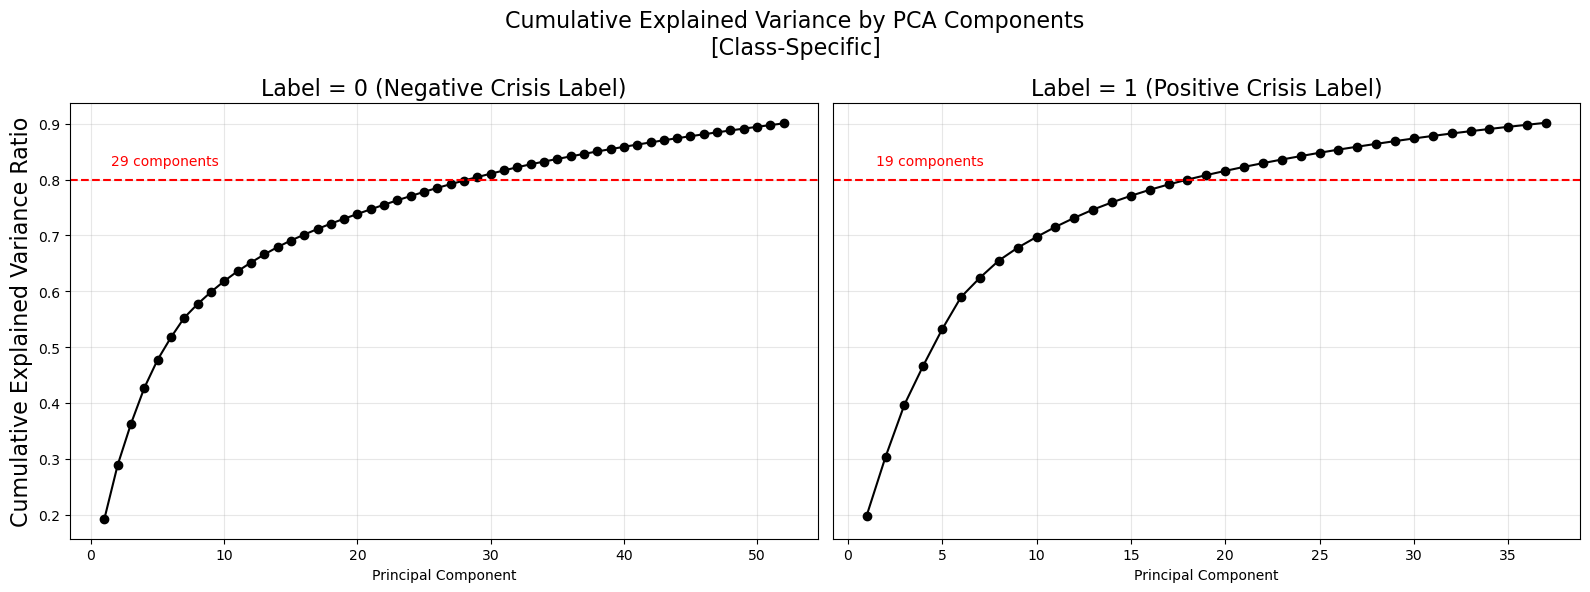

In [8]:
from src.features.pca import ClassSpecificPCA

cs_pca = ClassSpecificPCA(n_components=0.9)
cs_pca.fit(train_df, y_train)
cs_pca.plot_explained_variance(
    cumulative=True, title="Cumulative Explained Variance by PCA Components\n[Class-Specific]")

Note that for the Class Specific PCA, data across the positive and negative label classes are standardized together before fitting PCA on each subset independently. This is to match with how we would use this method to transform unlabelled data.

Investigating the composition of the principal components of the Class Specific PCA reveals a few things:
1. The top principal components for the majority class are dominated by features from the OECD database, which makes sense as they have monthly resolution while the others are annual and were forward filled 11 months.
2. The grouping of the first few principal components puts the raw OECD variables and the features that were engineered from them together. Interestingly, in the second and third PC, the top components include some World Bank and JST variables.
3. Even though the top principal components for the majority and minority class are different, the 2D feature space created by the Majority PC1 and Minority PC2 puts all the points near a diagonal, implying that the PCs represent similar underlying features.

A quick explanation of the prefixes of the variables listed below:
1. MABMM = Broad Money; MANMM = Narrow Money
2. IRSTC = Overnight interbank rate

In [9]:
print("Majority Class PCA Top Components:")
print(f"PC1: {cs_pca.get_top_components('majority', PC=1, n=5)}")
print(f"PC2: {cs_pca.get_top_components('majority', PC=2, n=5)}")
print(f"PC3: {cs_pca.get_top_components('majority', PC=3, n=5)}")
print(f"PC4: {cs_pca.get_top_components('majority', PC=4, n=5)}")
print(f"PC5: {cs_pca.get_top_components('majority', PC=5, n=5)}")
print("\n")
print("Minority Class PCA Top Components:")
print(f"PC1: {cs_pca.get_top_components('minority', PC=1, n=5)}")
print(f"PC2: {cs_pca.get_top_components('minority', PC=2, n=5)}")
print(f"PC3: {cs_pca.get_top_components('minority', PC=3, n=5)}")
print(f"PC4: {cs_pca.get_top_components('minority', PC=4, n=5)}")
print(f"PC5: {cs_pca.get_top_components('minority', PC=5, n=5)}")

Majority Class PCA Top Components:
PC1: ['MABMM301.ST.M_ewm_3', 'MABMM301.ST.M_rolling_3_min', 'MABMM301.ST.M_rolling_6_mean', 'MABMM301.ST.M_ewm_6', 'MABMM301.ST.M_rolling_6_min']
PC2: ['NE.CON.PRVT.PC.KD', 'NY.GDP.PCAP.KD', 'NE.EXP.GNFS.ZS', 'NE.TRD.GNFS.ZS', 'NE.IMP.GNFS.ZS']
PC3: ['MABMM301.GY.M', 'MABMM301.GY.M_rolling_6_max', 'MABMM301.GY.M_rolling_3_max', 'MABMM301.GP.M_rolling_6_mean', 'MABMM301.GP.M_ewm_6']
PC4: ['MABMM301.GY.M_seasonal_trend', 'MABMM301.GY.M', 'MABMM301.GY.M_rolling_3_min', 'MABMM301.GP.M_ewm_6', 'MABMM301.GY.M_rolling_6_min']
PC5: ['NAEXKP02.GY.Q_rolling_3_max', 'NAEXKP02.GY.Q_rolling_6_mean', 'NAEXKP02.GY.Q', 'NAEXKP02.GY.Q_rolling_3_min', 'NAEXKP02.GY.Q_rolling_3_mean']


Minority Class PCA Top Components:
PC1: ['NY.GDS.TOTL.CD', 'NE.DAB.TOTL.CD', 'NY.GDP.FCST.CD', 'NE.GDI.TOTL.CD', 'NE.GDI.FTOT.CD']
PC2: ['NE.GDI.TOTL.CN', 'NE.GDI.STKB.CN', 'NE.GDI.FTOT.KN', 'NE.RSB.GNFS.CD', 'NY.TTF.GNFS.KN']
PC3: ['imports', 'ca', 'tloans', 'narrowm', 'tmort']
PC4: ['NA

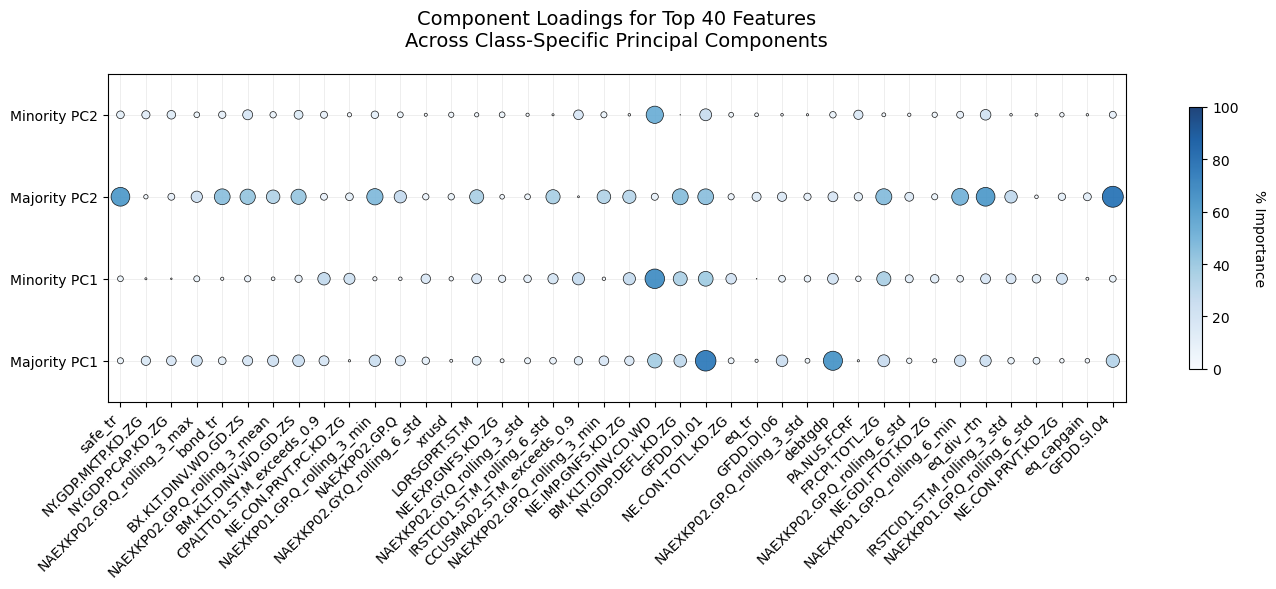

In [10]:
cs_pca.plot_component_loadings(n=40)

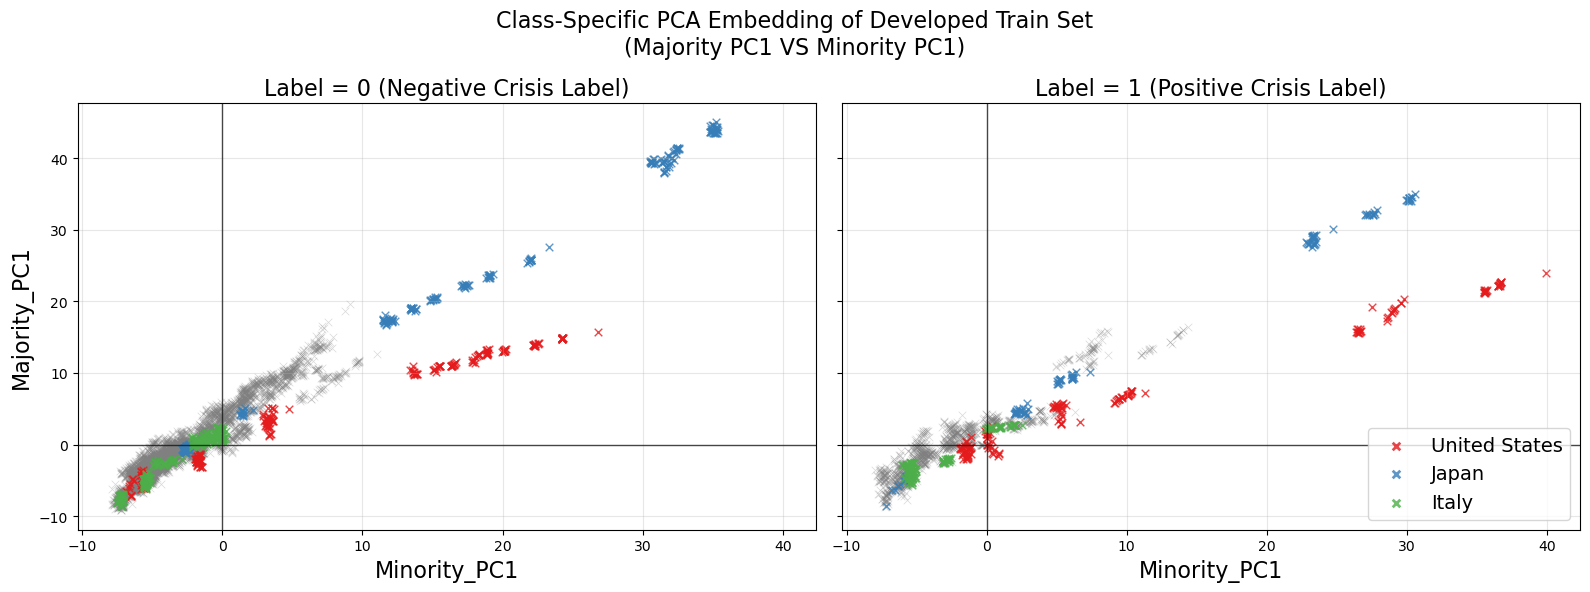

In [11]:
train_embeddings = cs_pca.transform(train_df)
cs_pca.plot_feature_space(
    train_embeddings[['Minority_PC1', 'Majority_PC1']],
    labels=y_train, color_by=train_df['Country'],
    highlight_categories=['United States','Japan','Italy'],
    title="Class-Specific PCA Embedding of Developed Train Set\n(Majority PC1 VS Minority PC1)")

It can be useful for a classification model to receive both the majority class PCA transformation and the minority class PCA transformation of a given dataset as inputs, especially if the transformations are sufficiently different and better able to separate the positive from negative crisis labels.

## t-distributed Stochastic Neighbor Embedding (t-SNE)

We use t-SNE to explore the value added by non-linear transformations. t-SNE shows even cleaner separation of the training data by country. However, the same concern exists in that the positive and negative crisis labels belong to the same clusters.

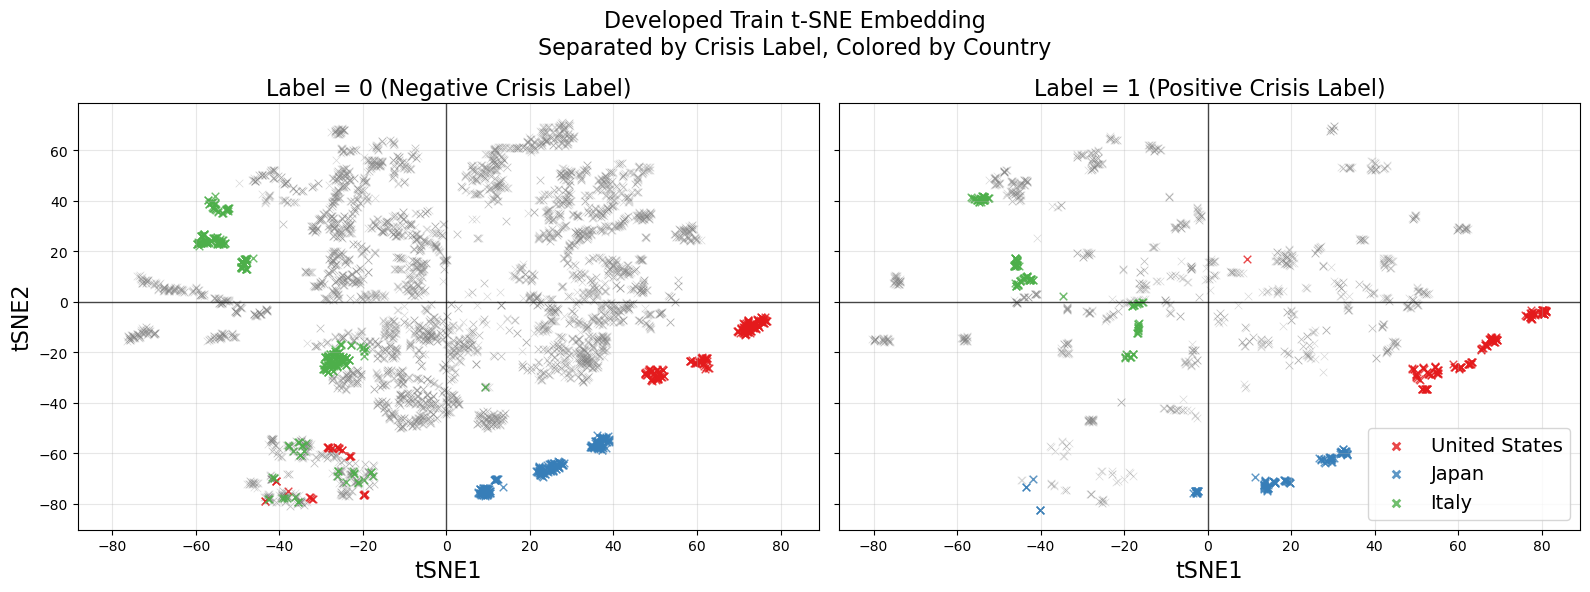

In [12]:
from src.features.tsne import BaseTSNE

tsne_class = BaseTSNE(n_components=2, perplexity=60, max_iter=1000)
embedding = tsne_class.fit_transform(train_df.drop(columns=['Country','Date']), y_train)
tsne_class.plot_feature_space(embedding, y_train,
                                color_by=train_df['Country'],
                                highlight_categories=['United States', 'Japan', 'Italy'],
                                title="Developed Train t-SNE Embedding\nSeparated by Crisis Label, Colored by Country")

In [13]:
print(f"Final KL Divergence: {tsne_class.get_kl_divergence():.4f}")

Final KL Divergence: 0.6863


Not shown is an exploration of UMAPs. Due to the high dimensionality of the data, it was first pre-processed using PCA. UMAPs have the added benefit of learning an embedding space that is supervised by the class labels. However, after testing many combinations of hyperparameters, it seemed that no learned embedding space that appropriately separated the training data by label was able to achieve this on the testing dataset.

## Variational Autoencoder (VAE)

We can also train a variational autoencoder and use the latent space as reduced dimensions of the original data. While it is not as straightforward as PCA to understand what the latent dimensions represent, we have the ability to tune the learning process to take advantage of the continuity of the latent space and potentially find regions where the hard-to-classify data live. This can be done by tuning the $\beta$ hyperparamter, which allows us to explore the trade-off between reconstruction error (i.e. data representation) and latent space structure (i.e. generalizability). As the goal is to reduce the dimensions of the data, we note that the reconstruction loss is large but we may not want to unnecessarily increase the dimensions of the latent space (`n_components`) if we are able to achieve sufficient separation of crisis and non-crisis labels in the feature space.

Model type: <class 'src.features.vae.BaseVAE'>


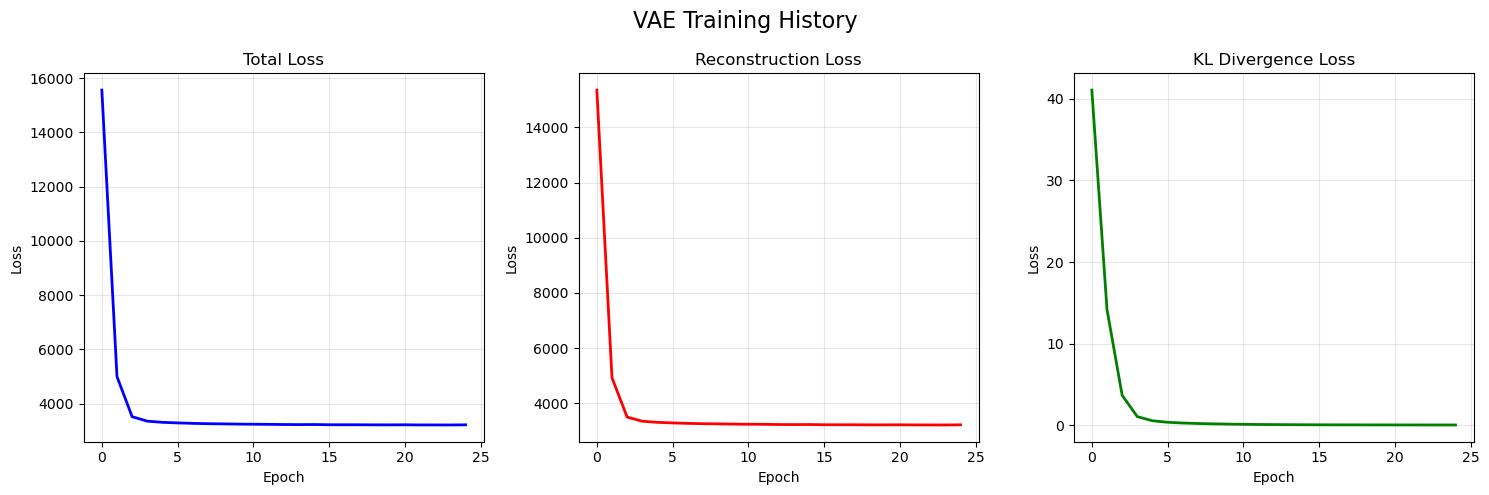

Train embedding shape: (7461, 8)


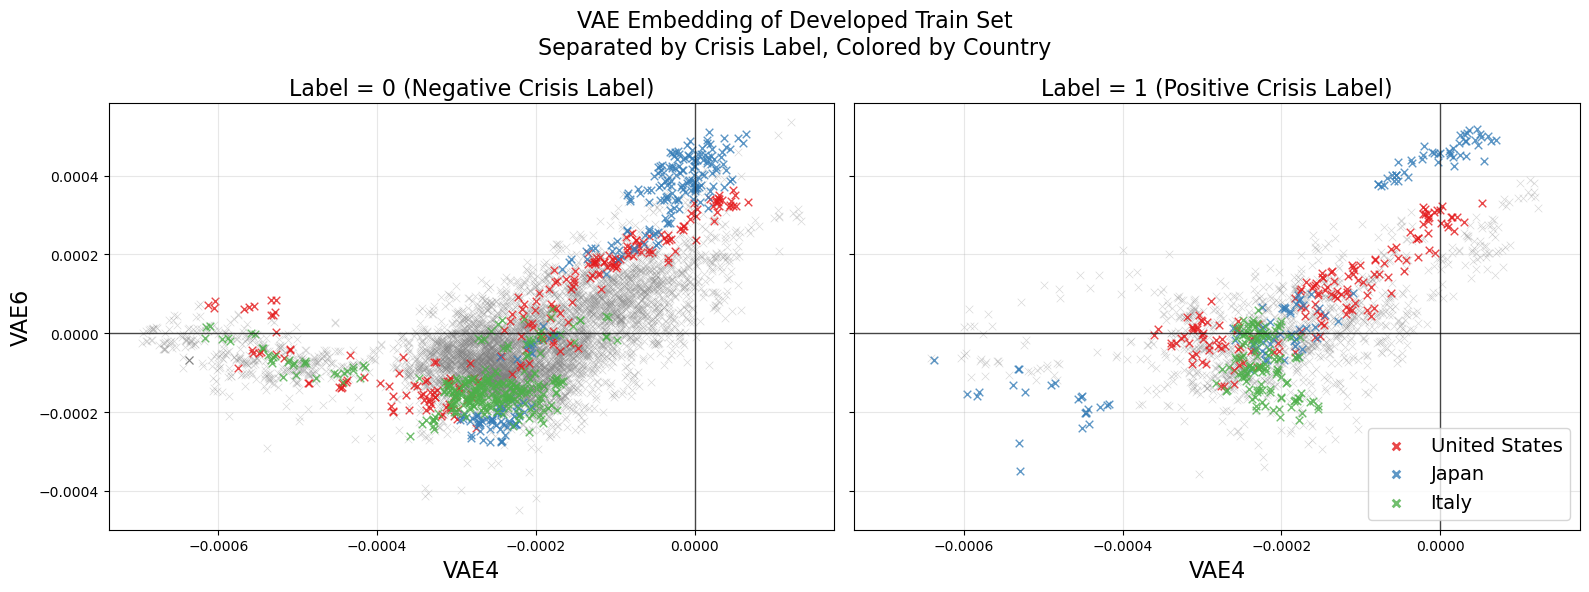

In [14]:
from src.features.vae import BaseVAE

params = {
    'n_components': 8,
    'learning_rate': 1e-3,
    'batch_size': 512,
    'hidden_dims': [256, 128, 64, 32, 16],
    'n_epochs': 25,
    'beta': 5.0,
}

# Load or train the VAE model
vae = load_or_train_model(
    model_class=BaseVAE,
    params=params,
    train_data=train_df.drop(columns=['Country', 'Date']),
    train_labels=y_train,
    force_retrain=True
)

print(f"Model type: {type(vae)}")
vae.plot_training_history()

# Prepare data for plotting (train set)
train_embedding = vae.transform(train_df.drop(columns=['Country', 'Date']))
print(f"Train embedding shape: {train_embedding.shape}")
plot_y_train = y_train[train_embedding.index]
plot_train_countries = train_df.loc[train_embedding.index, 'Country']

vae.plot_feature_space(
    train_embedding, labels=plot_y_train,
    color_by=plot_train_countries,
    highlight_categories=['United States','Japan','Italy'],
    title="VAE Embedding of Developed Train Set\nSeparated by Crisis Label, Colored by Country"
)

As with PCA, we can also train Class Specific VAEs and tune them such that we have a different model to represent each class. For the majority class, which represents a greater diversity of economic periods, it could be helpful to represent these periods in larger dimensions or to train a deeper network that is appropriately able to grapple with the economic range. Alternatively, maybe more latent dimensions are needed to overfit to the minority class, so that all crises in history are learned at high resolution.

The code for this concept has been developed and tested. You can train the models by initializing the following class object:
```python
from src.features.vae import ClassSpecificVAE

cs_vae = ClassSpecificVAE(
    majority_params={},
    minority_params={}
)
```
Due to time constraints and as Class Specific PCA did not yield promising results compared to its parent PCA method, we will not be exploring how a Class Specific VAE inputs integrate with downstream ML models to enhance overall performance.

## Time Series Encoding

The methods thus far express a snapshot of a country's economy in reduced dimensions and in relation to snapshots of other countries and/or other periods. RNNs, LSTMs and GRUs offers the abiity to better encapsulate an economic state in relation to history. We can train a VAE with an LSTM/GRU cell in the encoder and decoder such that the data input can now be a sequence of monthly economic variables instead of a single snapshot. This is useful for a few reasons:
1. The model has the means to understand overarching trends and outlier periods in the context of recent history
2. The crisis label is positive for a continuous period of two years before the actual crisis; receiving a sequence of data can allow the model to better represent the positive period instead of trying to guess the dicrete labels from monthly signals that could come from anywhere within this period of two years
3. The crises themselves occur at low frequencies and can last a few years; receiving a sequence of data that includes a part of a crisis period can give the model the necessary information to not predict a positive label soon after with more confidence. For this reason, we retain the in-crisis period for this group of dimensionality reduction methods.

The continuous latent space provides a way to understand how emerging markets are similar or contrasting to their developed neighbors. It is possible to relate the closeness of an emerging market to the training data with the predictive performance of a downstream model that receives this embedding. This forms the premise of ProtoNets, a subset of meta-learning techniques. However, due to time-constraints, we will not investigate this.

In [15]:
from src.model.utilities import set_seed, set_device
seed = set_seed()
device = set_device()

from src.features.utilities import load_or_train_model

import pandas as pd
import numpy as np

import os
import dotenv
dotenv.load_dotenv()
username = os.getenv("HUGGINGFACE_USERNAME")

from datasets import load_dataset

datalink = f"{username}/imputed-monthly"
train_df = load_dataset(datalink, "developed", split='train').to_pandas()
test_df = load_dataset(datalink, "developed", split='test').to_pandas()
support_df = load_dataset(datalink, "emerging", split='train').to_pandas()
query_df = load_dataset(datalink, "emerging", split='test').to_pandas()

from src.data.data_utilities import build_labels

y_train = build_labels(train_df)
y_test = build_labels(test_df)
y_support = build_labels(support_df)
y_query = build_labels(query_df)

print(f"Countries in developed train set: {train_df['Country'].unique()}")
print(f"Date range in developed train set: {train_df['Date'].min()} to {train_df['Date'].max()}")
print(f"Crises in developed train set: {y_train.mean() * 100:.2f}%")
print("\n")
print(f"Countries in developed test set: {test_df['Country'].unique()}")
print(f"Date range in developed test set: {test_df['Date'].min()} to {test_df['Date'].max()}")
print(f"Crises in developed test set: {y_test.mean() * 100:.2f}%")
print("\n")
print(f"Countries in emerging train set: {support_df['Country'].nunique()}")
print(f"Date range in emerging train set: {support_df['Date'].min()} to {support_df['Date'].max()}")
print(f"Crises in emerging train set: {y_support.mean() * 100:.2f}%")
print("\n")
print(f"Countries in emerging test set: {query_df['Country'].nunique()}")
print(f"Date range in emerging test set: {query_df['Date'].min()} to {query_df['Date'].max()}")
print(f"Crises in emerging test set: {y_query.mean() * 100:.2f}%")

No GPU available! Running on CPU
Countries in developed train set: ['Australia' 'Belgium' 'Canada' 'Denmark' 'Finland' 'France' 'Germany'
 'Italy' 'Japan' 'Netherlands' 'Norway' 'Portugal' 'Spain' 'Sweden'
 'Switzerland' 'United Kingdom' 'United States']
Date range in developed train set: 1960-01-31 00:00:00 to 2006-12-31 00:00:00
Crises in developed train set: 16.15%


Countries in developed test set: ['Australia' 'Belgium' 'Canada' 'Denmark' 'Finland' 'France' 'Germany'
 'Italy' 'Japan' 'Netherlands' 'Norway' 'Portugal' 'Spain' 'Sweden'
 'Switzerland' 'United Kingdom' 'United States']
Date range in developed test set: 2007-01-31 00:00:00 to 2023-12-31 00:00:00
Crises in developed test set: 6.92%


Countries in emerging train set: 73
Date range in emerging train set: 1962-12-31 00:00:00 to 2006-12-31 00:00:00
Crises in emerging train set: 16.31%


Countries in emerging test set: 73
Date range in emerging test set: 2007-01-31 00:00:00 to 2023-12-31 00:00:00
Crises in emerging test set:

### Time Series VAE

No GPU available! Running on CPU
Model type: <class 'src.features.vae.TimeSeriesVAE'>


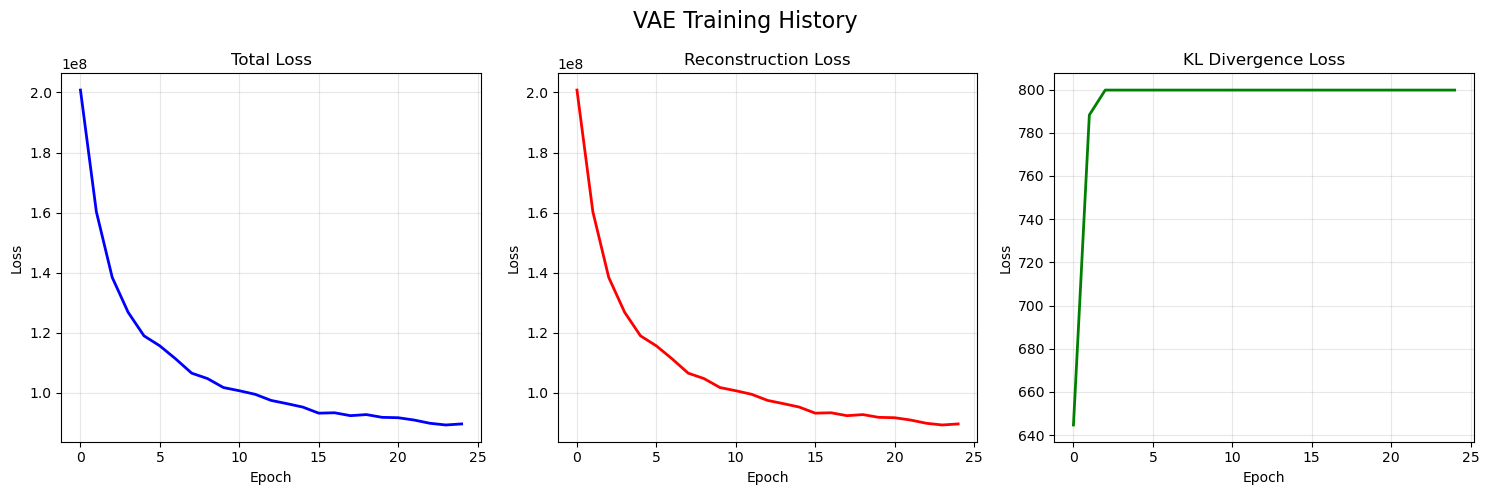

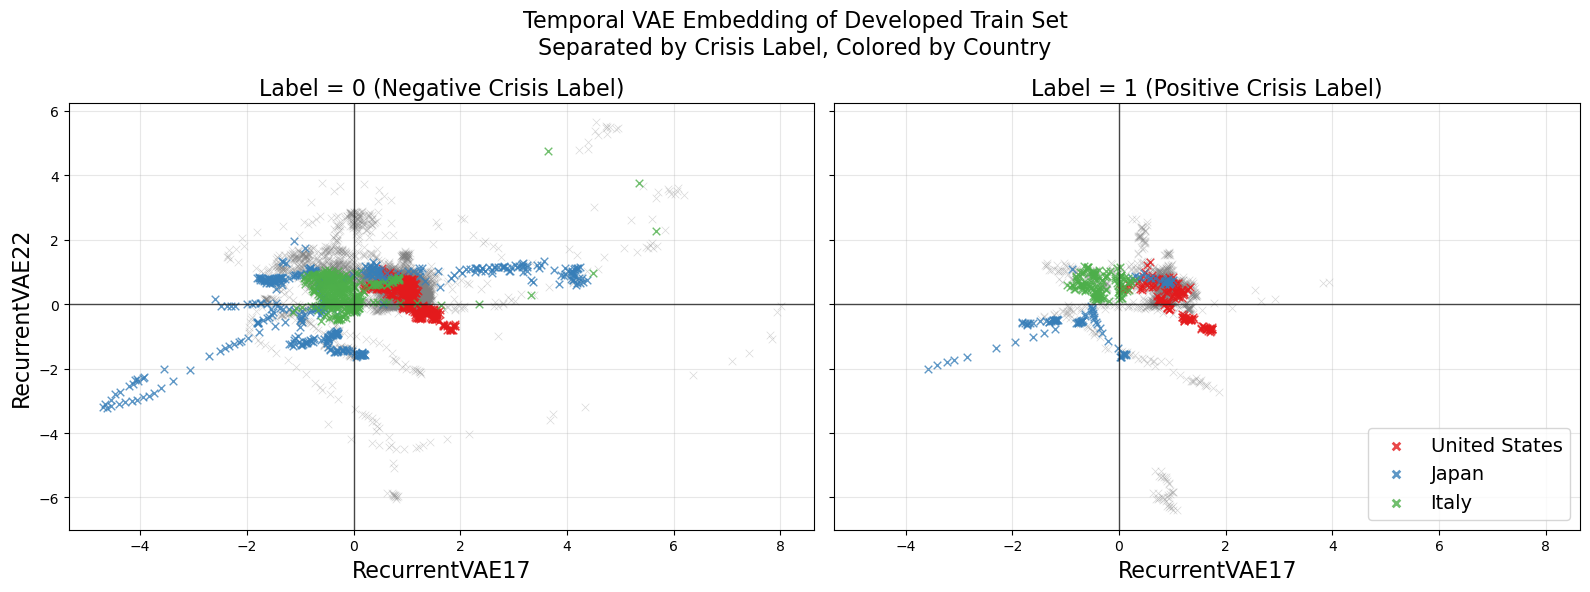

In [ ]:
from src.features.vae import TimeSeriesVAE

params = {
    'sequence_length': 24,
    'hidden_size': 128,
    'n_components': 32,
    'num_layers': 2,
    'block': 'GRU',
    'learning_rate': 1e-3,
    'batch_size': 16,
    'n_epochs': 25,
    'beta': 1.0,
    'KL_annealing': False,
}

# Load or train the TimeSeriesVAE model
ts_vae = load_or_train_model(
    model_class=TimeSeriesVAE,
    params=params,
    train_data=train_df,
    train_labels=y_train,
    force_retrain=True
)

# Plot training history
print(f"Model type: {type(ts_vae)}")
ts_vae.plot_training_history()

# Plot training data embeddings
train_embedding = ts_vae.transform(train_df)
plot_y_train = y_train[train_embedding.index]
plot_train_countries = train_df.loc[train_embedding.index, 'Country']

ts_vae.plot_feature_space(
    train_embedding, labels=plot_y_train,
    color_by=plot_train_countries,
    highlight_categories=['United States', 'Japan', 'Italy'],
    title="Temporal VAE Embedding of Developed Train Set\nSeparated by Crisis Label, Colored by Country"
)

### Time Series VAE + Residual Connections

A Time Series VAE struggles to train well if there are only a few latent dimensions as the reconstruction loss is prohibitively large and prevents any useful features from being learned. We can use residual connections to combat exploding gradients and encode more information such that the latent space need not be as large.

No GPU available! Running on CPU
Model type: <class 'src.features.unet.TimeSeriesUNET'>


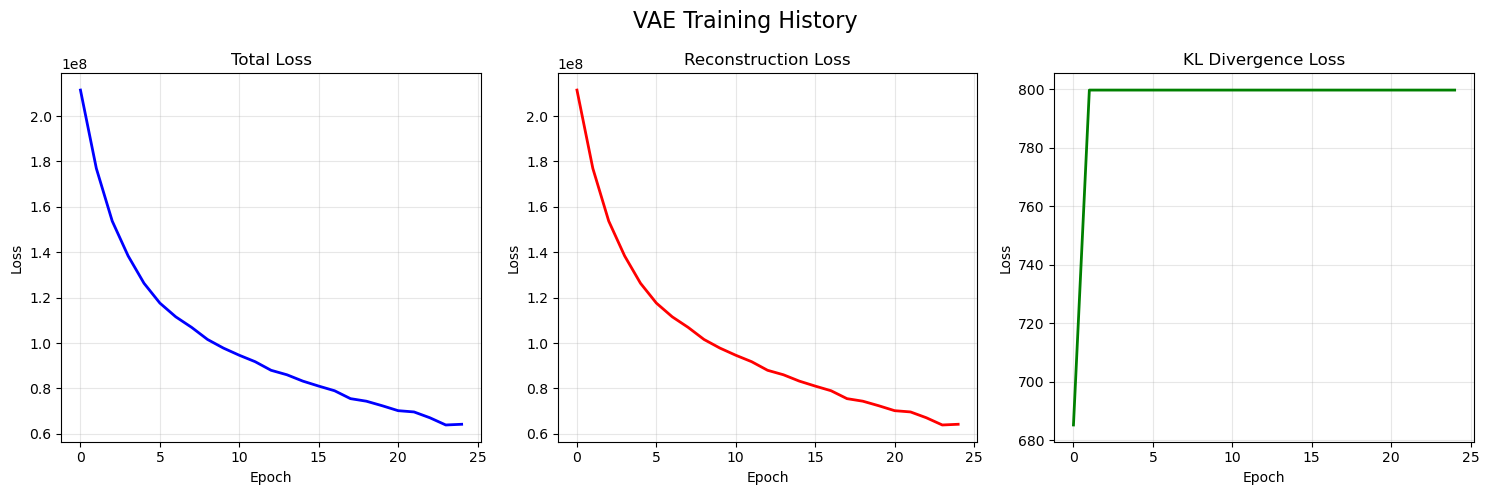

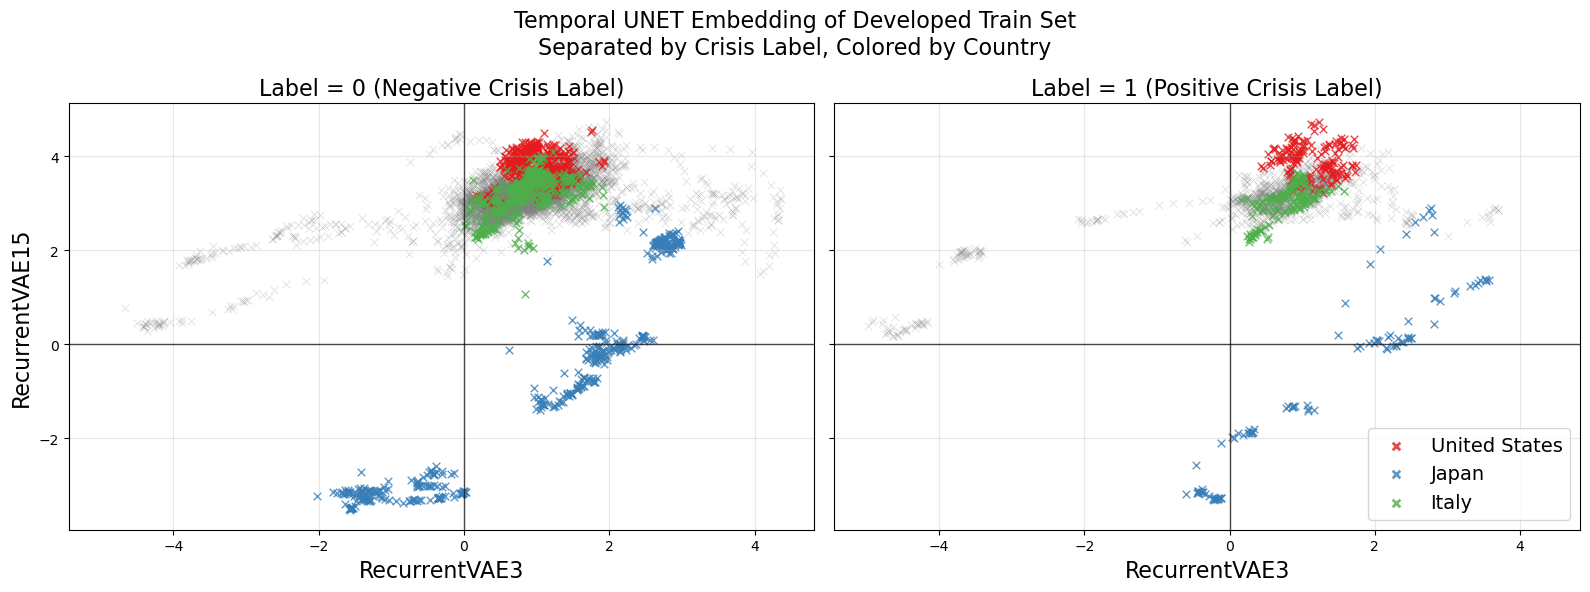

In [17]:
from src.features.unet import TimeSeriesUNET

params = {
    'sequence_length': 24,
    'hidden_size': 64,
    'n_components': 16,
    'num_layers': 5,
    'block': 'GRU',
    'learning_rate': 1e-3,
    'batch_size': 16,
    'n_epochs': 25,
    'beta': 1.0,
    'KL_annealing': False,
}

# Load or train the TimeSeriesUNET model
ts_unet = load_or_train_model(
    model_class=TimeSeriesUNET,
    params=params,
    train_data=train_df,
    train_labels=y_train,
    force_retrain=True
)

# Plot training history
print(f"Model type: {type(ts_unet)}")
ts_unet.plot_training_history()

# Plot training data embeddings
train_embedding = ts_unet.transform(train_df)
plot_y_train = y_train[train_embedding.index]
plot_train_countries = train_df.loc[train_embedding.index, 'Country']

ts_unet.plot_feature_space(
    train_embedding, labels=plot_y_train,
    color_by=plot_train_countries,
    highlight_categories=['United States', 'Japan', 'Italy'],
    title="Temporal UNET Embedding of Developed Train Set\nSeparated by Crisis Label, Colored by Country"
)